**DeepONet using DeepXDE module**

In [2]:
import deepxde as dde
import matplotlib.pyplot as plt
import numpy as np
import h5py
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import ReduceLROnPlateau

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Data loading

In [3]:
datastore = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/trials_many_alldata_new_eqution_halton.h5", 'r')
data_I = np.array(np.array(datastore["I"]))

data_c = np.array(np.array(datastore["c"]))
data_h = np.array(np.array(datastore["h"]))
t = np.linspace(0, 1, 601).reshape(601, 1)

In [4]:
datastore_glob = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/all_data_1d_glob.jld2", 'r')
print(datastore_glob.keys())
data_I_glob = np.array(np.array(datastore_glob["data_I"]))

data_c_glob = np.array(np.array(datastore_glob["data_c"]))
data_h_glob = np.array(np.array(datastore_glob["data_h"]))
para_glob = np.array(np.array(datastore_glob["para3"]))


<KeysViewHDF5 ['data_I', 'data_c', 'data_h', 'para3']>


Train-test split

In [5]:
train_label, test_label = train_test_split(range(len(data_I)), test_size=0.25, random_state=42)

data_i_train = data_I[train_label,:]
data_i_test = data_I[test_label,:]

data_c_train = data_c[train_label,:]
data_c_test = data_c[test_label,:]

data_h_train = data_h[train_label,:]
data_h_test = data_h[test_label,:]

In [6]:
X_train = (data_i_train.astype(np.float32), t.astype(np.float32))
y_train_c = data_c_train.astype(np.float32)

In [7]:
X_test = (data_i_test.astype(np.float32), t.astype(np.float32))
y_test_c = data_c_test.astype(np.float32)

**Making the data compatible with deepxde.nn.pytorch.deeponet.PODDeepONet**

In [8]:
data_c = dde.data.TripleCartesianProd(
    X_train=X_train, y_train=y_train_c, X_test=X_test, y_test=y_test_c
)

In [9]:
m = 601
dim_x = 1
net = dde.nn.DeepONetCartesianProd(
    [m, 200, 200, 100],
    [dim_x, 200, 200, 100],
    "relu",
    "Glorot normal",
)

**Counting the number of learnable parameters in the model**

In [10]:
def compute_parameters(layers):
    params = 0
    for i in range(len(layers) - 1):
        params += layers[i] * layers[i + 1]  # Weights
        params += layers[i + 1]             # Biases
    return params

branch_layers = [m, 200, 200, 100]
trunk_layers = [dim_x, 200, 200, 100]

branch_params = compute_parameters(branch_layers)
trunk_params = compute_parameters(trunk_layers)
total_params = branch_params + trunk_params
print(f"Total trainable parameters: {total_params}, branch parameters: {branch_params}, trunk parameters: {trunk_params}")


Total trainable parameters: 241400, branch parameters: 180700, trunk parameters: 60700


**Training the model**

In [11]:
model_c = dde.Model(data_c, net)
# lr = ReduceLROnPlateau(optimizer_combined, mode='min', factor=0.5, patience=5)
model_c.compile("adam", lr=0.001)
losshistory_c, train_state_c = model_c.train(iterations=1000, display_every=100)

Compiling model...
'compile' took 1.530206 s

Training model...

Step      Train loss    Test loss     Test metric
0         [1.64e+00]    [1.64e+00]    []  
100       [1.47e-01]    [1.47e-01]    []  
200       [1.10e-01]    [1.11e-01]    []  
300       [4.54e-02]    [4.57e-02]    []  
400       [3.26e-02]    [3.32e-02]    []  
500       [3.43e-02]    [3.50e-02]    []  
600       [6.17e-02]    [6.23e-02]    []  
700       [3.46e-02]    [3.50e-02]    []  
800       [2.73e-02]    [2.78e-02]    []  
900       [2.77e-02]    [2.84e-02]    []  
1000      [2.43e-02]    [2.48e-02]    []  

Best model at step 1000:
  train loss: 2.43e-02
  test loss: 2.48e-02
  test metric: []

'train' took 835.940540 s



In [12]:
y_train_h = data_h_train.astype(np.float32)
y_test_h = data_h_test.astype(np.float32)

In [13]:
data_h = dde.data.TripleCartesianProd(
    X_train=X_train, y_train=y_train_h, X_test=X_test, y_test=y_test_h
)

In [26]:
m = 601
dim_x = 1
net = dde.nn.DeepONetCartesianProd(
    [m, 300, 200, 100],
    [dim_x, 300, 200, 100],
    "relu",
    "Glorot normal",
)

In [27]:
model_h = dde.Model(data_h, net)
# lr = ReduceLROnPlateau(optimizer_combined, mode='min', factor=0.5, patience=5)
model_h.compile("adam", lr=0.001)
losshistory_h, train_state_h = model_h.train(iterations=2000, display_every=100)

Compiling model...
'compile' took 0.000326 s

Training model...

Step      Train loss    Test loss     Test metric
0         [3.05e-01]    [3.03e-01]    []  
100       [6.47e-02]    [6.50e-02]    []  
200       [6.38e-02]    [6.40e-02]    []  
300       [6.30e-02]    [6.33e-02]    []  
400       [6.90e-02]    [6.90e-02]    []  
500       [6.39e-02]    [6.40e-02]    []  
600       [6.08e-02]    [6.11e-02]    []  
700       [6.31e-02]    [6.34e-02]    []  
800       [6.21e-02]    [6.24e-02]    []  
900       [6.03e-02]    [6.08e-02]    []  
1000      [6.11e-02]    [6.15e-02]    []  
1100      [6.59e-02]    [6.60e-02]    []  
1200      [7.61e-02]    [7.68e-02]    []  
1300      [5.85e-02]    [5.86e-02]    []  
1400      [6.25e-02]    [6.30e-02]    []  
1500      [5.31e-02]    [5.34e-02]    []  
1600      [4.86e-02]    [4.88e-02]    []  
1700      [5.60e-02]    [5.61e-02]    []  
1800      [5.27e-02]    [5.29e-02]    []  
1900      [5.01e-02]    [5.05e-02]    []  
2000      [6.01e-02]    [

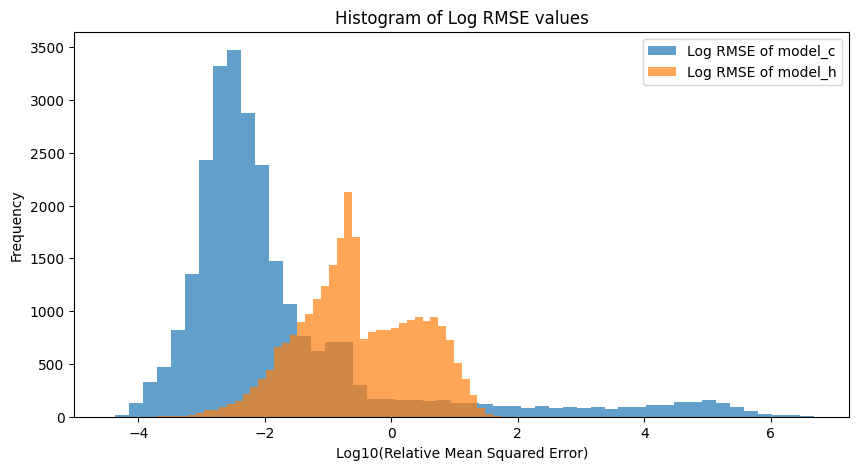

RMSE at c = 2: Mean = 0.07813682229356383, Std = 0.07831963751584277
RMSE at c = 2.5: Mean = 0.23973212420772147, Std = 0.20487764795708083
RMSE at c = 3: Mean = 0.9167436294692872, Std = 0.0


In [40]:
# Use trained model to make predictions
predictions_c = model_c.predict((data_i_test, t))  # Ensure model_c is defined
predictions_h = model_h.predict((data_i_test, t))  # Ensure model_h is defined

# Compute Relative Mean Squared Error (RMSE) for model_c
rmse_c = np.mean((predictions_c - data_c_test) ** 2 / (data_c_test ** 2 + 1e-8), axis=1)  # Averaging across time points
rmse_h = np.mean((predictions_h - data_h_test) ** 2 / (data_h_test ** 2 + 1e-8), axis=1)  # Averaging across time points

# Log-scale histogram
plt.figure(figsize=(10, 5))
plt.hist(np.log10(rmse_c + 1e-8), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rmse_h + 1e-8), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values')
plt.legend()
plt.show()

# Inspect performance for c = 2, 3, 4
special_points = [2, 2.5, 3]
errors_at_special_points = {str(point): [] for point in special_points}

for i in range(data_c_test.shape[0]):
    for point in special_points:
        if np.max(data_c_test[i])>=point:
            index = np.argmin(np.abs(data_c_test[i]-point))
            errors_at_special_points[str(point)].append(np.abs((predictions_c[i, index] - data_c_test[i, index])**2))

# Print analysis for special points
for point, errors in errors_at_special_points.items():
    if errors:
        print(f"RMSE at c = {point}: Mean = {np.mean(errors)}, Std = {np.std(errors)}")
    else:
        print(f"No data points found for c = {point}")


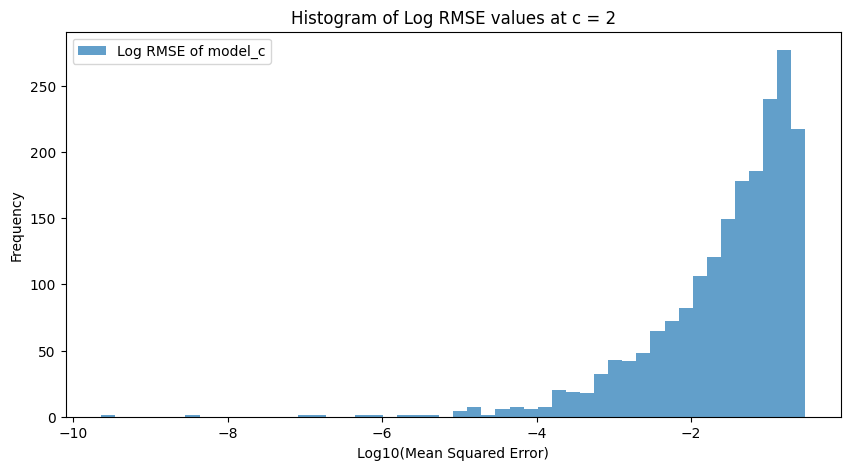

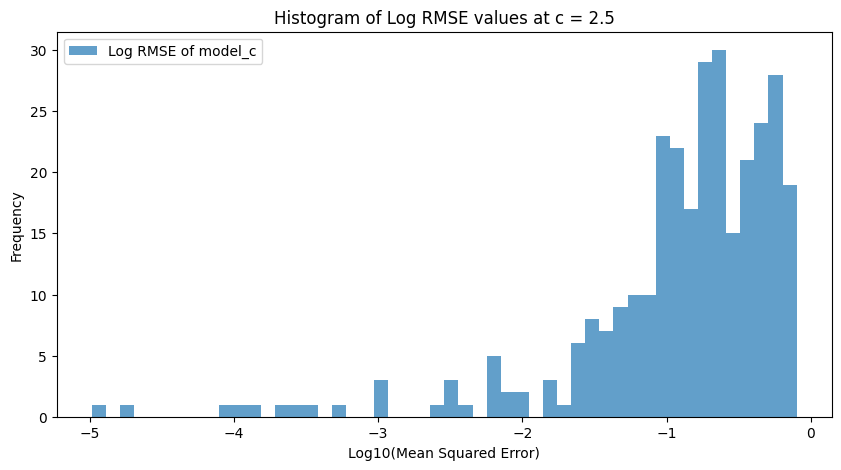

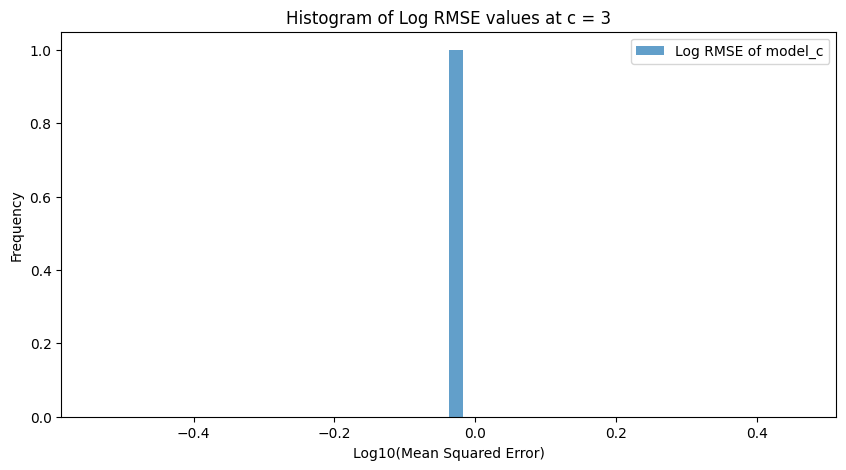

In [44]:
plt.figure(figsize=(10, 5))
plt.hist(np.log10([error + 1e-12 for error in errors_at_special_points["2"]]), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.xlabel('Log10(Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values at c = 2')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(np.log10([error + 1e-12 for error in errors_at_special_points["2.5"]]), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.xlabel('Log10(Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values at c = 2.5')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(np.log10([error + 1e-12 for error in errors_at_special_points["3"]]), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.xlabel('Log10(Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values at c = 3')
plt.legend()
plt.show()

In [45]:
def find_sharpest_decline_point(data, mesh=np.linspace(0, 1, 601)):
    """
    Identifies the point where the second derivative is smallest for each function in the input matrix.
    
    Parameters:
        data (numpy.ndarray): A matrix of shape [n, 601] where each row represents a discretized function.
        mesh (numpy.ndarray): The mesh points corresponding to the function values (default: linspace(0, 1, 601)).
    
    Returns:
        numpy.ndarray: An array of shape [n] containing the mesh points where the second derivative is minimum.
    """
    h = mesh[1] - mesh[0]  # Step size
    n = data.shape[0]

    # Compute second derivative using finite difference approximation
    second_derivative = (data[:, :-2] + data[:, 2:] - 2 * data[:, 1:-1]) / (h ** 2)

    # Find the index of the minimum second derivative for each row
    min_indices = np.argmin(second_derivative, axis=1)

    # Map indices to corresponding mesh points
    min_points = mesh[min_indices + 1]  # +1 because second_derivative skips first and last points

    return min_points, min_indices

In [46]:
sharpest_points, sharpest_indices = find_sharpest_decline_point(data_c_test)

errors_at_sharpest_points = []

for i in range(data_c_test.shape[0]):
    errors_at_sharpest_points.append(np.abs((predictions_c[i, sharpest_indices[i]] - data_c_test[i, sharpest_indices[i]])**2))


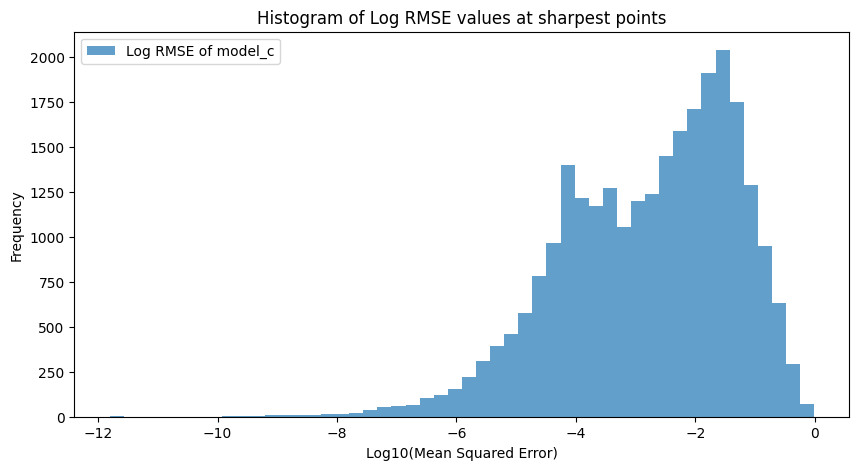

In [47]:
plt.figure(figsize=(10, 5))
plt.hist(np.log10([error + 1e-12 for error in errors_at_sharpest_points]), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.xlabel('Log10(Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values at sharpest points')
plt.legend()
plt.show()

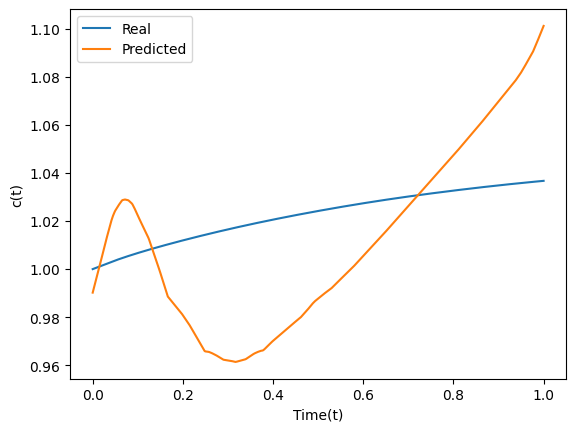

In [ ]:
n = np.random.randint(0, len(data_h_test))
pred_c = model_c.predict((data_i_test[n].reshape(1, -1), t))
plt.figure()
plt.plot(t, data_c_test[n], label="Real")
plt.plot(t, pred_c.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("c(t)")
plt.legend()
plt.show()

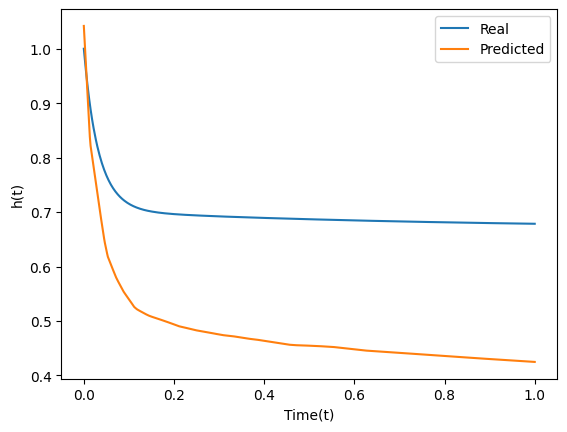

In [ ]:
pred_h = model_h.predict((data_i_test[n].reshape(1, -1), t))
plt.figure()
plt.plot(t, data_h_test[n], label="Real")
plt.plot(t, pred_h.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("h(t)")
plt.legend()
plt.show()

In [ ]:
# path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_c_deeponet"
# model_c.save(path)

In [ ]:
# path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_h_deeponet"
# model_h.save(path)

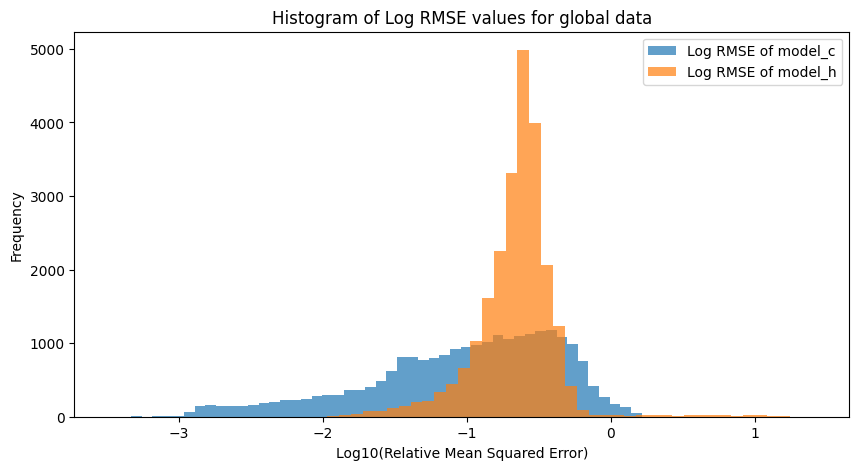

RMSE at c = 2: Mean = 1.178590178489685, Std = 0.8287045359611511
RMSE at c = 3: Mean = 4.48194694519043, Std = 1.3965551853179932
RMSE at c = 4: Mean = 9.484901428222656, Std = 2.0217111110687256


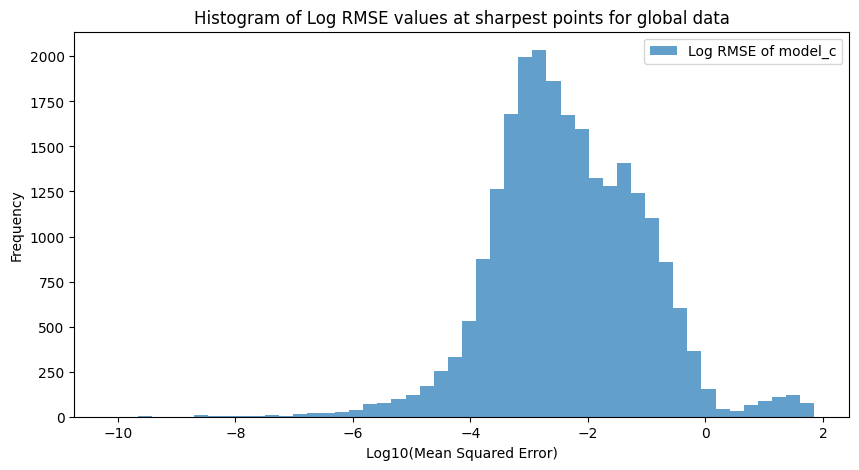

In [ ]:
# Prepare the test data
X_test_glob = (data_I_glob.astype(np.float32), t.astype(np.float32))
y_test_c_glob = data_c_glob.astype(np.float32)
y_test_h_glob = data_h_glob.astype(np.float32)

# Use trained models to make predictions
predictions_c_glob = model_c.predict(X_test_glob)
predictions_h_glob = model_h.predict(X_test_glob)

# Compute Relative Mean Squared Error (RMSE) for model_c
rmse_c_glob = np.mean((predictions_c_glob - y_test_c_glob) ** 2 / (y_test_c_glob ** 2 + 1e-12), axis=1)
rmse_h_glob = np.mean((predictions_h_glob - y_test_h_glob) ** 2 / (y_test_h_glob ** 2 + 1e-12), axis=1)

# Log-scale histogram
plt.figure(figsize=(10, 5))
plt.hist(np.log10(rmse_c_glob + 1e-8), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rmse_h_glob + 1e-8), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values for global data')
plt.legend()
plt.show()

# Inspect performance for c = 2, 3, 4
special_points_glob = [2, 3, 4]
errors_at_special_points_glob = {str(point): [] for point in special_points_glob}

for i in range(y_test_c_glob.shape[0]):
    for point in special_points_glob:
        if np.max(y_test_c_glob[i]) >= point:
            index = np.argmin(np.abs(y_test_c_glob[i] - point))
            errors_at_special_points_glob[str(point)].append(np.abs((predictions_c_glob[i, index] - y_test_c_glob[i, index]) ** 2))

# Print analysis for special points
for point, errors in errors_at_special_points_glob.items():
    if errors:
        print(f"RMSE at c = {point}: Mean = {np.mean(errors)}, Std = {np.std(errors)}")
    else:
        print(f"No data points found for c = {point}")

# Find the sharpest decline points
sharpest_points_glob, sharpest_indices_glob = find_sharpest_decline_point(y_test_c_glob)

errors_at_sharpest_points_glob = []

for i in range(y_test_c_glob.shape[0]):
    errors_at_sharpest_points_glob.append(np.abs((predictions_c_glob[i, sharpest_indices_glob[i]] - y_test_c_glob[i, sharpest_indices_glob[i]]) ** 2))

# Plot histogram of RMSE values at sharpest points
plt.figure(figsize=(10, 5))
plt.hist(np.log10([error + 1e-12 for error in errors_at_sharpest_points_glob]), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.xlabel('Log10(Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values at sharpest points for global data')
plt.legend()
plt.show()